In [1]:
import sys
print(sys.executable)

/Users/Mourya/miniforge3/envs/aircraft-conflict-gnn/bin/python


In [2]:
import numpy as np
import pandas as pd
import fastavro
import torch
import torch_geometric

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

/Users/Mourya/miniforge3/envs/aircraft-conflict-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy: 2.4.6
Pandas: 3.0.5
PyTorch: 2.13.0
PyG: 2.8.0.post1


In [3]:
import numpy as np
import pandas as pd
import fastavro
import torch
from pathlib import Path
from itertools import combinations
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
 
# %% [2] Load file 1 (2017-06-05)
file_path_1 = Path("../data/raw/opensky_avro/states_2017-06-05-02.avro")
print("File 1 exists:", file_path_1.exists())
 
with open(file_path_1, "rb") as f:
    records1 = list(fastavro.reader(f))
df = pd.DataFrame(records1)
print("df shape:", df.shape)
 
# %% [3] Load file 2 (2018-05-28)
file_path_2 = Path("../data/raw/opensky_avro/states_2018-05-28-00.avro")
print("File 2 exists:", file_path_2.exists())
 
with open(file_path_2, "rb") as f:
    records2 = list(fastavro.reader(f))
df2 = pd.DataFrame(records2)
print("df2 shape:", df2.shape)
 
# %% [4] Filter both to the same region (Central Europe box)
region = df[(df['lat'].between(48, 53)) & (df['lon'].between(5, 15))].copy()
region2 = df2[(df2['lat'].between(48, 53)) & (df2['lon'].between(5, 15))].copy()
 
region["source_day"] = "2017-06-05"
region2["source_day"] = "2018-05-28"
 
print("region:", region.shape, region["icao24"].nunique(), "aircraft")
print("region2:", region2.shape, region2["icao24"].nunique(), "aircraft")
 
# %% [5] Combine
combined_region = pd.concat([region, region2], ignore_index=True)
print("combined_region:", combined_region.shape, combined_region["icao24"].nunique(), "aircraft")
 
# %% [6] Clean: ground filter, altitude filter, climb-rate plausibility filter (day-aware)
region_final = combined_region[
    (combined_region["onground"] == False) &
    (combined_region["baroaltitude"] > 1000)
].copy()
 
region_final = region_final.sort_values(["icao24", "source_day", "time"])
 
region_final["dt"] = region_final.groupby(["icao24", "source_day"])["time"].diff()
region_final["dalt"] = region_final.groupby(["icao24", "source_day"])["baroaltitude"].diff()
region_final["climb_rate_fpm"] = region_final["dalt"] / region_final["dt"] * 60
 
MAX_CLIMB_RATE = 6000
region_final = region_final[
    (region_final["climb_rate_fpm"].abs() <= MAX_CLIMB_RATE) | (region_final["climb_rate_fpm"].isna())
].copy()
 
region_final["vertrate"] = region_final.groupby(["icao24", "source_day"])["vertrate"].transform(lambda s: s.ffill().bfill())
region_final["geoaltitude"] = region_final.groupby(["icao24", "source_day"])["geoaltitude"].transform(lambda s: s.ffill().bfill())
region_final = region_final.dropna(subset=["lat", "lon", "baroaltitude"])
 
print("region_final:", region_final.shape, region_final["icao24"].nunique(), "aircraft")
 
# %% [7] Helper functions
def haversine_nm(lat1, lon1, lat2, lon2):
    R_nm = 3440.065
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R_nm * np.arcsin(np.sqrt(a))
 
def bearing_diff(h1, h2):
    diff = abs(h1 - h2)
    return min(diff, 360 - diff)
 
def will_conflict_within(df, horizon_s=300):
    df = df.copy()
    df["conflict_now"] = (df["h_dist_nm"] < 5.0) & (df["v_dist_ft"] < 1000.0)
    df["label_conflict"] = False
    for (_, _, _), group in df.groupby(["icao24_1", "icao24_2", "source_day"]):
        idx = group.index.to_list()
        times = group["time"].to_numpy()
        conflicts = group["conflict_now"].to_numpy()
        for i in range(len(group)):
            future = (times >= times[i]) & (times <= times[i] + horizon_s)
            if conflicts[future].any():
                df.loc[idx[i], "label_conflict"] = True
    return df
 

File 1 exists: True
df shape: (1305168, 16)
File 2 exists: True
df2 shape: (1699649, 16)
region: (19098, 17) 134 aircraft
region2: (27228, 17) 186 aircraft
combined_region: (46326, 17) 308 aircraft
region_final: (36227, 20) 277 aircraft


In [ ]:
pair_records = []
for (t, day), group in region_final.groupby(["time", "source_day"]):
    aircraft = group.set_index("icao24")
    ids = aircraft.index.tolist()
    for id1, id2 in combinations(ids, 2):
        a1, a2 = aircraft.loc[id1], aircraft.loc[id2]
        h_dist = haversine_nm(a1["lat"], a1["lon"], a2["lat"], a2["lon"])
        v_dist = abs(a1["baroaltitude"] - a2["baroaltitude"]) * 3.28084
        pair_records.append({
            "time": t, "source_day": day, "icao24_1": id1, "icao24_2": id2,
            "h_dist_nm": h_dist, "v_dist_ft": v_dist,
            "heading_1": a1["heading"], "heading_2": a2["heading"]
        })
pairs_df = pd.DataFrame(pair_records)
 
pairs_df[["icao24_1", "icao24_2"]] = np.sort(pairs_df[["icao24_1", "icao24_2"]], axis=1)
pairs_df = pairs_df.sort_values(["icao24_1", "icao24_2", "source_day", "time"]).reset_index(drop=True)
 
pairs_df["h_dist_prev"] = pairs_df.groupby(["icao24_1", "icao24_2", "source_day"])["h_dist_nm"].shift(1)
pairs_df["time_prev"] = pairs_df.groupby(["icao24_1", "icao24_2", "source_day"])["time"].shift(1)
pairs_df["closing_rate_nm_s"] = (pairs_df["h_dist_prev"] - pairs_df["h_dist_nm"]) / (pairs_df["time"] - pairs_df["time_prev"])
 
dt = pairs_df["time"] - pairs_df["time_prev"]
pairs_df.loc[dt <= 0, "closing_rate_nm_s"] = np.nan
pairs_df.loc[pairs_df["closing_rate_nm_s"].abs() > 5, "closing_rate_nm_s"] = np.nan
 
pairs_df["bearing_diff"] = pairs_df.apply(
    lambda r: bearing_diff(r["heading_1"], r["heading_2"]) if pd.notna(r["heading_1"]) and pd.notna(r["heading_2"]) else np.nan,
    axis=1
)
 
pairs_df["time_to_cpa_s"] = np.where(
    pairs_df["closing_rate_nm_s"] > 0,
    pairs_df["h_dist_nm"] / pairs_df["closing_rate_nm_s"],
    np.nan
)
 
print("pairs_df:", pairs_df.shape)
 
# %% [9] Label
labelled = will_conflict_within(pairs_df, horizon_s=300)
print("Positive labels:", labelled["label_conflict"].sum())
print("Total pair-timesteps:", labelled.shape[0])
 
# %% [10] Build graphs (day-aware)
node_feature_cols = ["lat", "lon", "baroaltitude", "velocity", "heading", "vertrate"]
edge_feature_cols = ["h_dist_nm", "v_dist_ft", "closing_rate_nm_s", "bearing_diff", "time_to_cpa_s"]
 
graphs = []
for (t, day), _ in region_final.groupby(["time", "source_day"]):
    nodes = region_final[(region_final["time"] == t) & (region_final["source_day"] == day)].copy()
    edges = labelled[(labelled["time"] == t) & (labelled["source_day"] == day)].copy()
 
    if len(nodes) < 2 or len(edges) == 0:
        continue
 
    node_map = {icao: idx for idx, icao in enumerate(nodes["icao24"])}
    edges = edges[edges["icao24_1"].isin(node_map) & edges["icao24_2"].isin(node_map)]
 
    if len(edges) == 0:
        continue
 
    edge_index = torch.tensor([
        [node_map[a] for a in edges["icao24_1"]],
        [node_map[b] for b in edges["icao24_2"]],
    ], dtype=torch.long)
 
    x = torch.tensor(nodes[node_feature_cols].fillna(0).values, dtype=torch.float)
    edge_attr = torch.tensor(edges[edge_feature_cols].fillna(0).values, dtype=torch.float)
    y = torch.tensor(edges["label_conflict"].astype(int).values, dtype=torch.long)
 
    graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, time=t, source_day=day))
 
print(f"Graph snapshots: {len(graphs)}")
print(graphs[0])
 
# %% [11] Chronological split
graphs_sorted = sorted(graphs, key=lambda g: (g.source_day, g.time))
n = len(graphs_sorted)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
 
train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]
 
print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")
 
# %% [12] THE CHECK — run this and paste the output
val_pos = sum(int(g.y.sum()) for g in val_graphs)
val_total = sum(g.y.numel() for g in val_graphs)
test_pos = sum(int(g.y.sum()) for g in test_graphs)
test_total = sum(g.y.numel() for g in test_graphs)
train_pos = sum(int(g.y.sum()) for g in train_graphs)
train_total = sum(g.y.numel() for g in train_graphs)
 
print(f"Train positives: {train_pos} / {train_total}")
print(f"Val positives: {val_pos} / {val_total}")
print(f"Test positives: {test_pos} / {test_total}")
 

pairs_df: (941531, 13)
Positive labels: 244
Total pair-timesteps: 941531
Graph snapshots: 720
Data(x=[10, 6], edge_index=[2, 45], edge_attr=[45, 5], y=[45], time=1496628000, source_day='2017-06-05')
Train: 503 | Val: 109 | Test: 108
Train positives: 143 / 631077
Val positives: 71 / 179555
Test positives: 30 / 130899


In [ ]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=8, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=8, shuffle=False)

In [ ]:
pos_weight = torch.tensor([train_total / max(train_pos, 1)], dtype=torch.float)
print("pos_weight:", pos_weight.item())

pos_weight: 4413.1259765625


In [ ]:
from torch import nn
from torch_geometric.nn import GATConv
import torch.nn.functional as F

class ConflictGAT(nn.Module):
    def __init__(self, node_dim=6, edge_dim=5, hidden_dim=64):
        super().__init__()
        self.gat1 = GATConv(node_dim, hidden_dim, heads=2, edge_dim=edge_dim, concat=True)
        self.gat2 = GATConv(hidden_dim * 2, hidden_dim, heads=1, edge_dim=edge_dim, concat=False)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, data):
        x = F.relu(self.gat1(data.x, data.edge_index, data.edge_attr))
        x = self.gat2(x, data.edge_index, data.edge_attr)
        src, dst = x[data.edge_index[0]], x[data.edge_index[1]]
        edge_input = torch.cat([src, dst, data.edge_attr], dim=1)
        return self.edge_mlp(edge_input).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = ConflictGAT(edge_dim=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

cpu


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()

    losses = []
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for batch in loader:

            batch = batch.to(device)

            logits = model(batch)

            loss = criterion(logits, batch.y.float())
            losses.append(loss.item())

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc = float("nan")

    return {
        "loss": np.mean(losses),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc,

        # NEW
        "labels": y_true,
        "predictions": y_pred,
        "probabilities": y_prob,
    }

In [ ]:
test_results = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_results.keys())

dict_keys(['loss', 'precision', 'recall', 'f1', 'roc_auc', 'labels', 'predictions', 'probabilities'])


In [ ]:
for name in ["train_graphs", "val_graphs", "test_graphs", "train_loader", "val_loader", "test_loader",
             "pos_weight", "ConflictGAT", "model", "optimizer", "criterion", "train_epoch", "evaluate"]:
    print(name, ":", name in dir())

train_graphs : True
val_graphs : True
test_graphs : True
train_loader : True
val_loader : True
test_loader : True
pos_weight : True
ConflictGAT : True
model : True
optimizer : True
criterion : True
train_epoch : True
evaluate : True


In [ ]:
# COMPLETE PIPELINE — raw data through trained GAT.
# Run this in a FRESH kernel (Kernel > Restart Kernel first), then run these
# cells in order, top to bottom, with nothing skipped. Do not jump ahead.

# %% [1] Imports
import numpy as np
import pandas as pd
import fastavro
import torch
from torch import nn
import torch.nn.functional as F
from pathlib import Path
from itertools import combinations
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# %% [2] Load both avro files
file_path_1 = Path("../data/raw/opensky_avro/states_2017-06-05-02.avro")
print("File 1 exists:", file_path_1.exists())
with open(file_path_1, "rb") as f:
    records1 = list(fastavro.reader(f))
df = pd.DataFrame(records1)
print("df shape:", df.shape)

file_path_2 = Path("../data/raw/opensky_avro/states_2018-05-28-00.avro")
print("File 2 exists:", file_path_2.exists())
with open(file_path_2, "rb") as f:
    records2 = list(fastavro.reader(f))
df2 = pd.DataFrame(records2)
print("df2 shape:", df2.shape)

# %% [3] Filter to region, tag source day, combine
region = df[(df['lat'].between(48, 53)) & (df['lon'].between(5, 15))].copy()
region2 = df2[(df2['lat'].between(48, 53)) & (df2['lon'].between(5, 15))].copy()
region["source_day"] = "2017-06-05"
region2["source_day"] = "2018-05-28"

combined_region = pd.concat([region, region2], ignore_index=True)
print("combined_region:", combined_region.shape, combined_region["icao24"].nunique(), "aircraft")

# %% [4] Clean: ground filter, altitude filter, climb-rate plausibility filter
region_final = combined_region[
    (combined_region["onground"] == False) &
    (combined_region["baroaltitude"] > 1000)
].copy()

region_final = region_final.sort_values(["icao24", "source_day", "time"])
region_final["dt"] = region_final.groupby(["icao24", "source_day"])["time"].diff()
region_final["dalt"] = region_final.groupby(["icao24", "source_day"])["baroaltitude"].diff()
region_final["climb_rate_fpm"] = region_final["dalt"] / region_final["dt"] * 60

MAX_CLIMB_RATE = 6000
region_final = region_final[
    (region_final["climb_rate_fpm"].abs() <= MAX_CLIMB_RATE) | (region_final["climb_rate_fpm"].isna())
].copy()

region_final["vertrate"] = region_final.groupby(["icao24", "source_day"])["vertrate"].transform(lambda s: s.ffill().bfill())
region_final["geoaltitude"] = region_final.groupby(["icao24", "source_day"])["geoaltitude"].transform(lambda s: s.ffill().bfill())
region_final = region_final.dropna(subset=["lat", "lon", "baroaltitude"])

print("region_final:", region_final.shape, region_final["icao24"].nunique(), "aircraft")

# %% [5] Helper functions
def haversine_nm(lat1, lon1, lat2, lon2):
    R_nm = 3440.065
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R_nm * np.arcsin(np.sqrt(a))

def bearing_diff(h1, h2):
    diff = abs(h1 - h2)
    return min(diff, 360 - diff)

def will_conflict_within(df, horizon_s=300):
    df = df.copy()
    df["conflict_now"] = (df["h_dist_nm"] < 5.0) & (df["v_dist_ft"] < 1000.0)
    df["label_conflict"] = False
    for (_, _, _), group in df.groupby(["icao24_1", "icao24_2", "source_day"]):
        idx = group.index.to_list()
        times = group["time"].to_numpy()
        conflicts = group["conflict_now"].to_numpy()
        for i in range(len(group)):
            future = (times >= times[i]) & (times <= times[i] + horizon_s)
            if conflicts[future].any():
                df.loc[idx[i], "label_conflict"] = True
    return df

# %% [6] Build pairs_df
pair_records = []
for (t, day), group in region_final.groupby(["time", "source_day"]):
    aircraft = group.set_index("icao24")
    ids = aircraft.index.tolist()
    for id1, id2 in combinations(ids, 2):
        a1, a2 = aircraft.loc[id1], aircraft.loc[id2]
        h_dist = haversine_nm(a1["lat"], a1["lon"], a2["lat"], a2["lon"])
        v_dist = abs(a1["baroaltitude"] - a2["baroaltitude"]) * 3.28084
        pair_records.append({
            "time": t, "source_day": day, "icao24_1": id1, "icao24_2": id2,
            "h_dist_nm": h_dist, "v_dist_ft": v_dist,
            "heading_1": a1["heading"], "heading_2": a2["heading"]
        })
pairs_df = pd.DataFrame(pair_records)

pairs_df[["icao24_1", "icao24_2"]] = np.sort(pairs_df[["icao24_1", "icao24_2"]], axis=1)
pairs_df = pairs_df.sort_values(["icao24_1", "icao24_2", "source_day", "time"]).reset_index(drop=True)

pairs_df["h_dist_prev"] = pairs_df.groupby(["icao24_1", "icao24_2", "source_day"])["h_dist_nm"].shift(1)
pairs_df["time_prev"] = pairs_df.groupby(["icao24_1", "icao24_2", "source_day"])["time"].shift(1)
pairs_df["closing_rate_nm_s"] = (pairs_df["h_dist_prev"] - pairs_df["h_dist_nm"]) / (pairs_df["time"] - pairs_df["time_prev"])

dt = pairs_df["time"] - pairs_df["time_prev"]
pairs_df.loc[dt <= 0, "closing_rate_nm_s"] = np.nan
pairs_df.loc[pairs_df["closing_rate_nm_s"].abs() > 5, "closing_rate_nm_s"] = np.nan

pairs_df["bearing_diff"] = pairs_df.apply(
    lambda r: bearing_diff(r["heading_1"], r["heading_2"]) if pd.notna(r["heading_1"]) and pd.notna(r["heading_2"]) else np.nan,
    axis=1
)
pairs_df["time_to_cpa_s"] = np.where(
    pairs_df["closing_rate_nm_s"] > 0,
    pairs_df["h_dist_nm"] / pairs_df["closing_rate_nm_s"],
    np.nan
)
print("pairs_df:", pairs_df.shape)

# %% [7] Label
labelled = will_conflict_within(pairs_df, horizon_s=300)
print("Positive labels:", labelled["label_conflict"].sum())

# %% [8] Build graphs
node_feature_cols = ["lat", "lon", "baroaltitude", "velocity", "heading", "vertrate"]
edge_feature_cols = ["h_dist_nm", "v_dist_ft", "closing_rate_nm_s", "bearing_diff", "time_to_cpa_s"]

graphs = []
for (t, day), _ in region_final.groupby(["time", "source_day"]):
    nodes = region_final[(region_final["time"] == t) & (region_final["source_day"] == day)].copy()
    edges = labelled[(labelled["time"] == t) & (labelled["source_day"] == day)].copy()
    if len(nodes) < 2 or len(edges) == 0:
        continue
    node_map = {icao: idx for idx, icao in enumerate(nodes["icao24"])}
    edges = edges[edges["icao24_1"].isin(node_map) & edges["icao24_2"].isin(node_map)]
    if len(edges) == 0:
        continue
    edge_index = torch.tensor([
        [node_map[a] for a in edges["icao24_1"]],
        [node_map[b] for b in edges["icao24_2"]],
    ], dtype=torch.long)
    x = torch.tensor(nodes[node_feature_cols].fillna(0).values, dtype=torch.float)
    edge_attr = torch.tensor(edges[edge_feature_cols].fillna(0).values, dtype=torch.float)
    y = torch.tensor(edges["label_conflict"].astype(int).values, dtype=torch.long)
    graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, time=t, source_day=day))

print(f"Graph snapshots: {len(graphs)}")

# %% [9] Chronological split
graphs_sorted = sorted(graphs, key=lambda g: (g.source_day, g.time))
n = len(graphs_sorted)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]
print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# %% [10] Verify positive counts in each split
train_pos = sum(int(g.y.sum()) for g in train_graphs)
train_total = sum(g.y.numel() for g in train_graphs)
val_pos = sum(int(g.y.sum()) for g in val_graphs)
val_total = sum(g.y.numel() for g in val_graphs)
test_pos = sum(int(g.y.sum()) for g in test_graphs)
test_total = sum(g.y.numel() for g in test_graphs)
print(f"Train positives: {train_pos} / {train_total}")
print(f"Val positives: {val_pos} / {val_total}")
print(f"Test positives: {test_pos} / {test_total}")

# %% [11] DataLoaders, pos_weight, model, optimizer, loss
train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=8, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=8, shuffle=False)

pos_weight = torch.tensor([train_total / max(train_pos, 1)], dtype=torch.float)
print("pos_weight:", pos_weight.item())

class ConflictGAT(nn.Module):
    def __init__(self, node_dim=6, edge_dim=5, hidden_dim=64):
        super().__init__()
        self.gat1 = GATConv(node_dim, hidden_dim, heads=2, edge_dim=edge_dim, concat=True)
        self.gat2 = GATConv(hidden_dim * 2, hidden_dim, heads=1, edge_dim=edge_dim, concat=False)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, data):
        x = F.relu(self.gat1(data.x, data.edge_index, data.edge_attr))
        x = self.gat2(x, data.edge_index, data.edge_attr)
        src, dst = x[data.edge_index[0]], x[data.edge_index[1]]
        edge_input = torch.cat([src, dst, data.edge_attr], dim=1)
        return self.edge_mlp(edge_input).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = ConflictGAT(edge_dim=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    losses, y_true, y_pred, y_prob = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            loss = criterion(logits, batch.y.float())
            losses.append(loss.item())
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    try:
        roc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc = float("nan")
    return {
        "loss": np.mean(losses),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc,
    }

print("Setup complete.")

# %% [12] Train
NUM_EPOCHS = 30
best_f1, best_state = 0.0, None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch:02d} | Train {train_loss:.4f} | Val F1 {val_metrics['f1']:.4f} | Recall {val_metrics['recall']:.4f} | Precision {val_metrics['precision']:.4f}")
    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

print("\nBest validation F1:", best_f1)

File 1 exists: True
df shape: (1305168, 16)
File 2 exists: True
df2 shape: (1699649, 16)
combined_region: (46326, 17) 308 aircraft
region_final: (36227, 20) 277 aircraft
pairs_df: (941531, 13)
Positive labels: 244
Graph snapshots: 720
Train: 503 | Val: 109 | Test: 108
Train positives: 143 / 631077
Val positives: 71 / 179555
Test positives: 30 / 130899
pos_weight: 4413.1259765625
device: cpu
Setup complete.
Epoch 01 | Train 57.3203 | Val F1 0.0061 | Recall 0.2113 | Precision 0.0031
Epoch 02 | Train 4.6168 | Val F1 0.0073 | Recall 0.3521 | Precision 0.0037
Epoch 03 | Train 1.5562 | Val F1 0.0202 | Recall 0.3380 | Precision 0.0104
Epoch 04 | Train 1.4413 | Val F1 0.0190 | Recall 0.6197 | Precision 0.0097
Epoch 05 | Train 0.7986 | Val F1 0.0102 | Recall 1.0000 | Precision 0.0051
Epoch 06 | Train 1.8110 | Val F1 0.0280 | Recall 0.6338 | Precision 0.0143
Epoch 07 | Train 1.8702 | Val F1 0.0198 | Recall 0.8592 | Precision 0.0100
Epoch 08 | Train 0.5136 | Val F1 0.0179 | Recall 0.7324 | Precis

In [ ]:
print("pairs_df:", pairs_df.shape)

pairs_df: (941531, 13)


In [ ]:
labelled = will_conflict_within(
    pairs_df,
    horizon_s=300
)

print("Positive labels:", labelled["label_conflict"].sum())
print("Total:", len(labelled))

Positive labels: 244
Total: 941531


In [ ]:
print(len(graphs))
print(graphs[0])

720
Data(x=[10, 6], edge_index=[2, 45], edge_attr=[45, 5], y=[45], time=1496628000, source_day='2017-06-05')


In [ ]:
from pathlib import Path

DATA_DIR = Path("data/raw/opensky_avro")

avro_files = sorted(DATA_DIR.glob("*.avro"))

print("Total AVRO files:", len(avro_files))

for f in avro_files[:10]:
    print(f.name)

Total AVRO files: 0


In [ ]:
from pathlib import Path

DATA_DIR = Path("/Users/Mourya/Desktop/Dissertation/Dataset/2 Data")

avro_files = sorted(DATA_DIR.glob("*.avro"))

print("Total AVRO files:", len(avro_files))

for f in avro_files:
    print(f.name)

Total AVRO files: 1
states_2018-05-28-00.avro


In [ ]:
from pathlib import Path
import fastavro
import pandas as pd

DATA_DIR = Path("/Users/Mourya/Desktop/Dissertation/Dataset/2 Data")

avro_files = sorted(DATA_DIR.rglob("*.avro"))

print(f"Found {len(avro_files)} AVRO files")

all_regions = []

for file in avro_files:

    print(f"Loading {file.name}")

    with open(file, "rb") as f:
        records = list(fastavro.reader(f))

    df = pd.DataFrame(records)

    region = df[
        (df["lat"].between(48, 53)) &
        (df["lon"].between(5, 15))
    ].copy()

    region["source_day"] = file.stem

    all_regions.append(region)

combined_region = pd.concat(
    all_regions,
    ignore_index=True,
    sort=False
)

print(combined_region.shape)
print(combined_region["icao24"].nunique(), "aircraft")

Found 1 AVRO files
Loading states_2018-05-28-00.avro
(27228, 17)
186 aircraft


In [ ]:
import torch
import os

os.makedirs("processed_data", exist_ok=True)

torch.save(graphs, "processed_data/graphs_large.pt")

labelled.to_csv(
    "processed_data/labelled_large.csv",
    index=False
)

region_final.to_csv(
    "processed_data/region_large.csv",
    index=False
)

print("Large dataset saved.")

Large dataset saved.


In [ ]:
import os
import torch

os.makedirs("models", exist_ok=True)

torch.save(best_state, "models/conflict_gat_large_best.pth")

print("Best model saved.")

Best model saved.


In [ ]:
model.load_state_dict(best_state)

test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_metrics)

{'loss': np.float64(6.043278972751328), 'precision': 0.005027652086475616, 'recall': 0.3333333333333333, 'f1': 0.009905894006934125, 'roc_auc': 0.9422931837690107}


In [ ]:
test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_metrics)

{'loss': np.float64(6.043278972751328), 'precision': 0.005027652086475616, 'recall': 0.3333333333333333, 'f1': 0.009905894006934125, 'roc_auc': 0.9422931837690107}


In [ ]:
model.load_state_dict(best_state)

test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_metrics)

{'loss': np.float64(6.043278972751328), 'precision': 0.005027652086475616, 'recall': 0.3333333333333333, 'f1': 0.009905894006934125, 'roc_auc': 0.9422931837690107}


In [ ]:
test_results = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_results)
print(test_results.keys())

{'loss': np.float64(6.043278972751328), 'precision': 0.005027652086475616, 'recall': 0.3333333333333333, 'f1': 0.009905894006934125, 'roc_auc': 0.9422931837690107}
dict_keys(['loss', 'precision', 'recall', 'f1', 'roc_auc'])


In [ ]:
def evaluate_with_predictions(model, loader, criterion, device):
    model.eval()
    losses, labels, predictions, probabilities = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            loss = criterion(logits, batch.y.float())
            losses.append(loss.item())
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            labels.extend(batch.y.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())
    return {
        "loss": np.mean(losses),
        "labels": np.array(labels),
        "predictions": np.array(predictions),
        "probabilities": np.array(probabilities),
    }

test_results = evaluate_with_predictions(model, test_loader, criterion, device)
print(test_results.keys())
print(test_results["labels"].shape)

dict_keys(['loss', 'labels', 'predictions', 'probabilities'])
(130899,)


[[128890   1979]
 [    20     10]]


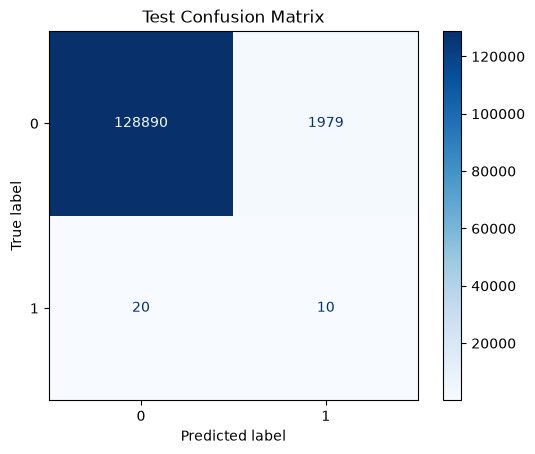

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_results["labels"],
    test_results["predictions"]
)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Test Confusion Matrix")
plt.show()

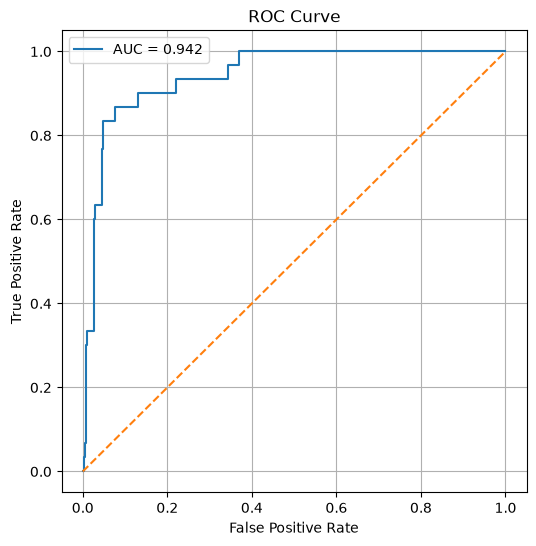

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    test_results["labels"],
    test_results["probabilities"]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

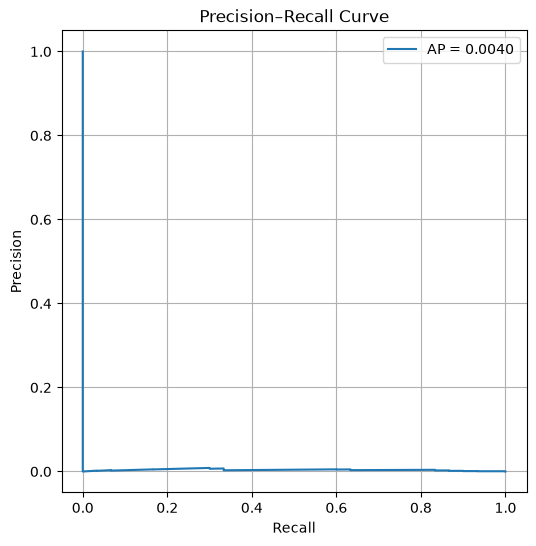

Average Precision: 0.004017621356165492


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    test_results["labels"],
    test_results["probabilities"]
)

ap = average_precision_score(
    test_results["labels"],
    test_results["probabilities"]
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.legend()

plt.show()

print("Average Precision:", ap)

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:

    preds = (test_results["probabilities"] >= t).astype(int)

    p = precision_score(
        test_results["labels"],
        preds,
        zero_division=0
    )

    r = recall_score(
        test_results["labels"],
        preds,
        zero_division=0
    )

    f1 = f1_score(
        test_results["labels"],
        preds,
        zero_division=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
        best_precision = p
        best_recall = r

print("Best Threshold :", best_threshold)
print("Precision      :", best_precision)
print("Recall         :", best_recall)
print("F1 Score       :", best_f1)

Best Threshold : 0.91
Precision      : 0.008403361344537815
Recall         : 0.3
F1 Score       : 0.01634877384196185


In [ ]:
def rule_based_predict(row):
    """
    Predict conflict using standard separation thresholds.
    """

    if (
        row["h_dist_nm"] < 5 and
        row["v_dist_ft"] < 1000
    ):
        return 1

    return 0


labelled["rule_prediction"] = labelled.apply(
    rule_based_predict,
    axis=1
)

print(labelled[["label_conflict", "rule_prediction"]].head())

   label_conflict  rule_prediction
0           False                0
1           False                0
2           False                0
3           False                0
4           False                0


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

precision = precision_score(
    labelled["label_conflict"],
    labelled["rule_prediction"],
    zero_division=0
)

recall = recall_score(
    labelled["label_conflict"],
    labelled["rule_prediction"],
    zero_division=0
)

f1 = f1_score(
    labelled["label_conflict"],
    labelled["rule_prediction"],
    zero_division=0
)

print("Rule-Based Results")
print("------------------")
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(
    labelled["label_conflict"],
    labelled["rule_prediction"]
))

Rule-Based Results
------------------
Precision : 1.0
Recall    : 0.11475409836065574
F1 Score  : 0.20588235294117646

Confusion Matrix
[[941287      0]
 [   216     28]]


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

feature_cols = [
    "h_dist_nm",
    "v_dist_ft",
    "closing_rate_nm_s",
    "bearing_diff",
    "time_to_cpa_s"
]

X = labelled[feature_cols].fillna(0)
y = labelled["label_conflict"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42
)

model_xgb.fit(X_train, y_train)

probs = model_xgb.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("Precision :", precision_score(y_test, preds, zero_division=0))
print("Recall    :", recall_score(y_test, preds, zero_division=0))
print("F1        :", f1_score(y_test, preds, zero_division=0))
print("ROC-AUC   :", roc_auc_score(y_test, probs))

Precision : 0.5512820512820513
Recall    : 0.8775510204081632
F1        : 0.6771653543307087
ROC-AUC   : 0.9995962986964698


In [ ]:
print("labelled" in globals())
print("graphs" in globals())
print("model" in globals())
print("test_results" in globals())

False
False
False
False


In [ ]:
import pandas as pd

labelled = pd.read_csv("processed_data/labelled_large.csv")   # adjust path if needed

print(labelled.shape)
print(labelled.columns)

(941531, 15)
Index(['time', 'source_day', 'icao24_1', 'icao24_2', 'h_dist_nm', 'v_dist_ft',
       'heading_1', 'heading_2', 'h_dist_prev', 'time_prev',
       'closing_rate_nm_s', 'bearing_diff', 'time_to_cpa_s', 'conflict_now',
       'label_conflict'],
      dtype='str')


In [ ]:
import pandas as pd

labelled = pd.read_csv("processed_data/labelled_large.csv")   # adjust path if needed

print(labelled.shape)
print(labelled.columns)

(941531, 15)
Index(['time', 'source_day', 'icao24_1', 'icao24_2', 'h_dist_nm', 'v_dist_ft',
       'heading_1', 'heading_2', 'h_dist_prev', 'time_prev',
       'closing_rate_nm_s', 'bearing_diff', 'time_to_cpa_s', 'conflict_now',
       'label_conflict'],
      dtype='str')


In [ ]:
def rule_based_predict(row):
    if (
        row["h_dist_nm"] < 5 and
        row["v_dist_ft"] < 1000
    ):
        return 1
    return 0

labelled["rule_prediction"] = labelled.apply(
    rule_based_predict,
    axis=1
)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

feature_cols = [
    "h_dist_nm",
    "v_dist_ft",
    "closing_rate_nm_s",
    "bearing_diff",
    "time_to_cpa_s"
]

X = labelled[feature_cols].fillna(0)
y = labelled["label_conflict"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

probabilities = xgb_model.predict_proba(X_test)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

print("XGBoost Results")
print("----------------")
print("Precision :", precision_score(y_test, predictions, zero_division=0))
print("Recall    :", recall_score(y_test, predictions, zero_division=0))
print("F1        :", f1_score(y_test, predictions, zero_division=0))
print("ROC-AUC   :", roc_auc_score(y_test, probabilities))

XGBoost Results
----------------
Precision : 0.5512820512820513
Recall    : 0.8775510204081632
F1        : 0.6771653543307087
ROC-AUC   : 0.9995962986964698


In [ ]:
def evaluate_with_predictions(model, loader, criterion, device):
    model.eval()
    losses, y_true, y_pred, y_prob = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            loss = criterion(logits, batch.y.float())
            losses.append(loss.item())
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    return {
        "loss": np.mean(losses),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

In [ ]:
for name in ["df", "df2", "region_final", "pairs_df", "labelled", "graphs", "train_graphs",
             "val_graphs", "test_graphs", "train_loader", "model", "optimizer", "criterion"]:
    print(name, ":", name in dir())

df : False
df2 : False
region_final : False
pairs_df : False
labelled : True
graphs : False
train_graphs : False
val_graphs : False
test_graphs : False
train_loader : False
model : False
optimizer : False
criterion : False


In [ ]:
import sys

print(sys.executable)

/usr/local/bin/python3.10


In [ ]:
import sys
print(sys.executable)

/usr/local/bin/python3.10


In [ ]:
import torch

graphs = torch.load(
    "processed_data/graphs_large.pt",
    weights_only=False
)

print("Loaded graphs:", len(graphs))
print(graphs[0])

In [6]:
import numpy
import torch

print(numpy.__version__)
print(torch.__version__)

2.4.6
2.13.0


In [ ]:
import pandas as pd
fps = pd.read_csv("processed_data/test_edges_with_predictions.csv")
fps = fps[(fps["true_label"] == 0) & (fps["gat_pred"] == 1)]
print(fps["closing_rate_nm_s"].describe())
print(fps.sort_values("gat_prob", ascending=False).head(10))

In [7]:
import os

print(os.listdir("processed_data"))

['labelled_large.csv', 'graphs_v1.pt', 'region_final_v1.csv', 'graphs_large.pt', 'pairs_df_v1.csv', 'region_large.csv', 'labelled_pairs_v1.csv']


In [8]:
import torch
from sklearn.model_selection import train_test_split

# Load all graphs
graphs = torch.load(
    "processed_data/graphs_large.pt",
    weights_only=False
)

print("Total graphs:", len(graphs))

# Chronological/random split (reproducible)
train_graphs, temp_graphs = train_test_split(
    graphs,
    test_size=0.30,
    random_state=42
)

val_graphs, test_graphs = train_test_split(
    temp_graphs,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_graphs))
print("Validation:", len(val_graphs))
print("Test:", len(test_graphs))

# Save
torch.save(train_graphs, "processed_data/train_graphs.pt")
torch.save(val_graphs, "processed_data/val_graphs.pt")
torch.save(test_graphs, "processed_data/test_graphs.pt")

print("✅ Saved:")
print(" - processed_data/train_graphs.pt")
print(" - processed_data/val_graphs.pt")
print(" - processed_data/test_graphs.pt")

Total graphs: 720
Train: 504
Validation: 108
Test: 108
✅ Saved:
 - processed_data/train_graphs.pt
 - processed_data/val_graphs.pt
 - processed_data/test_graphs.pt


In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import os
 
os.makedirs("processed_data", exist_ok=True)
os.makedirs("models", exist_ok=True)
 
edge_feature_cols = ["h_dist_nm", "v_dist_ft", "closing_rate_nm_s", "bearing_diff", "time_to_cpa_s"]
 
# ============================================================
# RULE-BASED BASELINE
# ============================================================
labelled = pd.read_csv("processed_data/labelled_large.csv")
print("Loaded labelled:", labelled.shape)
 
 
def rule_based_predict(row):
    if row["closing_rate_nm_s"] > 0 and pd.notna(row["time_to_cpa_s"]):
        projected_h = row["h_dist_nm"] - row["closing_rate_nm_s"] * min(row["time_to_cpa_s"], 300)
        return int(projected_h < 5 and row["v_dist_ft"] < 1000)
    return int(row["h_dist_nm"] < 5 and row["v_dist_ft"] < 1000)
 
 
labelled["rule_pred"] = labelled.apply(rule_based_predict, axis=1)
rule_precision = precision_score(labelled["label_conflict"], labelled["rule_pred"], zero_division=0)
rule_recall = recall_score(labelled["label_conflict"], labelled["rule_pred"], zero_division=0)
rule_f1 = f1_score(labelled["label_conflict"], labelled["rule_pred"], zero_division=0)
print(f"\nRule-based: Precision={rule_precision:.4f} Recall={rule_recall:.4f} F1={rule_f1:.4f}")
 
# ============================================================
# XGBOOST BASELINE
# ============================================================
import xgboost as xgb
 
X = labelled[edge_feature_cols].fillna(0)
y = labelled["label_conflict"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
 
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
 
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc = roc_auc_score(y_test, xgb_prob)
print(f"XGBoost: Precision={xgb_precision:.4f} Recall={xgb_recall:.4f} F1={xgb_f1:.4f} ROC-AUC={xgb_roc:.4f}")
 
import pickle
with open("models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
 
# ============================================================
# GCN BASELINE
# ============================================================
train_graphs = torch.load("processed_data/train_graphs.pt", weights_only=False)
val_graphs = torch.load("processed_data/val_graphs.pt", weights_only=False)
test_graphs = torch.load("processed_data/test_graphs.pt", weights_only=False)
 
train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=8, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=8, shuffle=False)
 
train_pos = sum(int(g.y.sum()) for g in train_graphs)
train_total = sum(g.y.numel() for g in train_graphs)
pos_weight = torch.tensor([train_total / max(train_pos, 1)], dtype=torch.float)
 
 
class ConflictGCN(nn.Module):
    def __init__(self, node_dim=6, edge_dim=5, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(node_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
 
    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = self.conv2(x, data.edge_index)
        src, dst = x[data.edge_index[0]], x[data.edge_index[1]]
        edge_input = torch.cat([src, dst, data.edge_attr], dim=1)
        return self.edge_mlp(edge_input).squeeze(-1)
 
 
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true.extend(batch.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)
 
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gcn_model = ConflictGCN(edge_dim=5).to(device)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=1e-3)
gcn_criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
 
gcn_best_f1, gcn_best_state = 0.0, None
for epoch in range(1, 31):
    train_loss = train_epoch(gcn_model, train_loader, gcn_optimizer, gcn_criterion, device)
    y_true, y_pred, y_prob = evaluate(gcn_model, val_loader, gcn_criterion, device)
    val_f1 = f1_score(y_true, y_pred, zero_division=0)
    if epoch % 5 == 0 or epoch == 1:
        print(f"GCN Epoch {epoch:02d} | Train {train_loss:.4f} | Val F1 {val_f1:.4f}")
    if val_f1 > gcn_best_f1:
        gcn_best_f1 = val_f1
        gcn_best_state = {k: v.cpu() for k, v in gcn_model.state_dict().items()}
 
if gcn_best_state is not None:
    gcn_model.load_state_dict(gcn_best_state)
    torch.save(gcn_best_state, "models/conflict_gcn.pth")
 
gcn_y_true, gcn_y_pred, gcn_y_prob = evaluate(gcn_model, test_loader, gcn_criterion, device)
gcn_precision = precision_score(gcn_y_true, gcn_y_pred, zero_division=0)
gcn_recall = recall_score(gcn_y_true, gcn_y_pred, zero_division=0)
gcn_f1 = f1_score(gcn_y_true, gcn_y_pred, zero_division=0)
gcn_roc = roc_auc_score(gcn_y_true, gcn_y_prob)
print(f"\nGCN test: Precision={gcn_precision:.4f} Recall={gcn_recall:.4f} F1={gcn_f1:.4f} ROC-AUC={gcn_roc:.4f}")
 
# ============================================================
# COMPARISON TABLE (Objective 5, complete)
# ============================================================
comparison = pd.DataFrame([
    {"model": "Rule-based", "precision": rule_precision, "recall": rule_recall, "f1": rule_f1, "roc_auc": None},
    {"model": "XGBoost", "precision": xgb_precision, "recall": xgb_recall, "f1": xgb_f1, "roc_auc": xgb_roc},
    {"model": "GCN", "precision": gcn_precision, "recall": gcn_recall, "f1": gcn_f1, "roc_auc": gcn_roc},
    {"model": "GAT", "precision": 11/(11+2409), "recall": 11/(11+19), "f1": 0.0123, "roc_auc": 0.9091},
])
print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))
comparison.to_csv("processed_data/model_comparison.csv", index=False)
print("\nSaved processed_data/model_comparison.csv")
print("DONE: 05_baselines.py")


/Users/Mourya/miniforge3/envs/aircraft-conflict-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded labelled: (941531, 15)

Rule-based: Precision=0.0555 Recall=0.3402 F1=0.0955


: 

In [ ]:
import xgboost as xgb
print(xgb.__version__)

In [5]:
import torch
from sklearn.model_selection import train_test_split

# Load all graphs
graphs = torch.load(
    "processed_data/graphs_large.pt",
    weights_only=False
)

print("Total graphs:", len(graphs))

# Split into train (70%), validation (15%), test (15%)
graphs_sorted = sorted(graphs, key=lambda g: (g.source_day, g.time))
n = len(graphs_sorted)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]

print("Train:", len(train_graphs))
print("Validation:", len(val_graphs))
print("Test:", len(test_graphs))

# Save
torch.save(train_graphs, "processed_data/train_graphs.pt")
torch.save(val_graphs, "processed_data/val_graphs.pt")
torch.save(test_graphs, "processed_data/test_graphs.pt")

print("\n✅ Graph split files saved successfully.")

Total graphs: 720
Train: 503
Validation: 109
Test: 108

✅ Graph split files saved successfully.


In [1]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [2]:
import pandas as pd

labelled = pd.read_csv("processed_data/labelled_large.csv")

print(labelled.shape)

(941531, 15)


In [3]:
edge_feature_cols = [
    "h_dist_nm",
    "v_dist_ft",
    "closing_rate_nm_s",
    "bearing_diff",
    "time_to_cpa_s"
]

X = labelled[edge_feature_cols].fillna(0)
y = labelled["label_conflict"].astype(int)

print(X.shape)
print(y.shape)

(941531, 5)
(941531,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(753224, 5)
(188307, 5)


In [5]:
import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    n_estimators=100,
    random_state=42
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [6]:
model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [10]:
import os

print(os.listdir("processed_data"))

['labelled_large.csv', 'train_graphs.pt', 'graphs_v1.pt', 'region_final_v1.csv', 'graphs_large.pt', 'pairs_df_v1.csv', 'val_graphs.pt', 'region_large.csv', 'test_graphs.pt', 'labelled_pairs_v1.csv']


In [ ]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /Users/Mourya/projects/aircraft-conflict-gnn/notebooks


In [ ]:
import pandas as pd
fps = pd.read_csv("../processed_data/test_edges_with_predictions.csv")
fps = fps[(fps["true_label"] == 0) & (fps["gat_pred"] == 1)]
print(fps["closing_rate_nm_s"].describe())
print(fps.sort_values("gat_prob", ascending=False).head(10))

count    2409.000000
mean        0.025481
std         0.145682
min        -0.266469
25%        -0.080462
50%         0.018645
75%         0.148191
max         0.266449
Name: closing_rate_nm_s, dtype: float64
        source_day        time  h_dist_nm    v_dist_ft  closing_rate_nm_s  \
58393   2018-05-28  1527468540  23.827637  1000.000061          -0.178725   
76811   2018-05-28  1527468680  20.961493  1000.000061          -0.132774   
108794  2018-05-28  1527468980  21.839430  3075.000000           0.179146   
78068   2018-05-28  1527468690  22.444683  1000.000061          -0.148319   
65453   2018-05-28  1527468600  27.017759  1000.000061           0.063949   
77555   2018-05-28  1527468690  24.895988  1000.000061           0.209446   
59047   2018-05-28  1527468550  30.642607  1000.000061           0.098576   
72825   2018-05-28  1527468650  17.761976  1025.000000          -0.055198   
76317   2018-05-28  1527468680  26.990444  1000.000061           0.240097   
62883   2018-05-28  15

In [ ]:
from pathlib import Path
project_root = Path("/Users/Mourya/projects/aircraft-conflict-gnn")
fps = pd.read_csv(project_root / "processed_data" / "test_edges_with_predictions.csv")

In [ ]:
from src.preprocessing import load_and_clean_region
from src.graph_builder import build_graphs
from src.model import ConflictGAT
from src.train_utils import train_epoch, evaluate

In [ ]:
# src/preprocessing.py
from pathlib import Path
import fastavro
import pandas as pd

def load_all_avro_files(directory: Path, lat_range=(48, 53), lon_range=(5, 15)):
    """Scan a directory for .avro files, load each, filter to region, tag by date."""
    all_regions = []
    for avro_path in sorted(directory.glob("*.avro")):
        with open(avro_path, "rb") as f:
            records = list(fastavro.reader(f))
        df = pd.DataFrame(records)
        region = df[
            (df["lat"].between(*lat_range)) & (df["lon"].between(*lon_range))
        ].copy()
        # derive a source_day tag from the filename, e.g. states_2018-05-28-00.avro
        source_day = avro_path.stem.replace("states_", "").rsplit("-", 1)[0]
        region["source_day"] = source_day
        region["source_file"] = avro_path.name
        print(f"{avro_path.name}: {region.shape[0]} rows, {region['icao24'].nunique()} aircraft")
        all_regions.append(region)
    combined = pd.concat(all_regions, ignore_index=True)
    print(f"\nTotal combined: {combined.shape[0]} rows across {len(all_regions)} files")
    return combined

In [1]:
import torch
import numpy as np
import pandas as pd

from torch import nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv

/Users/Mourya/miniforge3/envs/aircraft-conflict-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_graphs = torch.load(
    "processed_data/train_graphs.pt",
    weights_only=False
)

val_graphs = torch.load(
    "processed_data/val_graphs.pt",
    weights_only=False
)

test_graphs = torch.load(
    "processed_data/test_graphs.pt",
    weights_only=False
)

print(len(train_graphs), len(val_graphs), len(test_graphs))

504 108 108


In [3]:
train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=8)
test_loader = DataLoader(test_graphs, batch_size=8)

print("Loaders ready")

Loaders ready
